# National Parks and National Change

## Group Name: The Correlators
### Group Members:
- Anvi Mehta
- Jamal Moussa 
- Katie Bakkonnen
- Mia George



# Introduction

Hiking is more than just a pastime for many; it's an experience that connects us with nature, offering both physical and mental rejuvenation. With this in mind, we aim to address the following key question:

How do periods of societal change and disturbance influence patterns of visitation in national parks, including but not limited to political elections, public health crises, and economic downturns?

Understanding how major events affect park visitation provides insights into human behavior under conditions of stress and uncertainty. This research seeks to identify correlations between unforeseen major events and park usage to help us gain a broader understanding of the interplay between society and the environment.

In [1]:
# Imports
import pandas as pd
import numpy as np
# from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt 
from tkinter import END
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import re
import os

# Datasets

We are using the following datasets to explore our question. Two of these datasets are from the government (National Park Service and National Archives) and one is from the MIT Election Data + Science Lab.

National Park Dataset

This dataset has the visitation data for all of the National Parks in the US. We will focus on the parks that are in the Continental United States. Each field was reported as a monthly total for each month of every year from 1979 to present. There is also annual data from 1904-1979. This dataset has around 35,000 samples. Something interesting that we observed from the data is the difference in visitors between 2019 and 2020. For example, in Yosemite, which is in a blue state, from August 2019 to August 2020 visitation dropped by 47%. In Arches, which is in a red state, from August 2019 to August 2020 visitation dropped by only 11%. We thought that it would be interesting to explore these trends in all of the states.

Electoral College Dataset, Presidential Candidate Dataset

The first link above has the electoral college results for every election starting from 1789. The tables have the state, presidential and vice-president candidate and how many electoral votes they each got. The second link contains the party of every presidential candidate. We selected these two datasets because we wanted to use the electoral college data by state to see if national park visitation was affected based on political leanings, but a lot of cleaning is needed for it to be usable since we only want the state, electoral college votes, presidential candidate, and their party.


# EDA & Preprocessing

If you have tableau visualizations, include the link.


# Analysis & Modeling


### Linear Regression

During the first stages of our data modeling, we tried to use a linear regression model on the yearly average data for each park from 1904-2024. We trained the model on the first 80% of the data available for each park and then tried to predict what number of visitors for the remaining 20% of the years would be. This modeling was not very accurate, with the R2 score for many parks being very small or even negative. The examples shown below show a few of the predictions that were made with linear regression. As you can see, the data was not entirely linear which meant that this model was not a good fit. We decided not to use the results from this model in our final predictions for outlier years.


showing


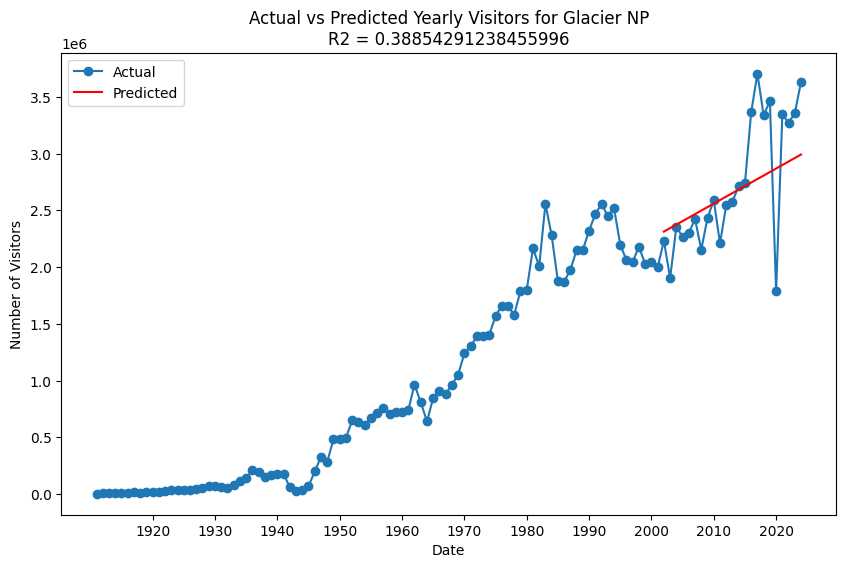

showing


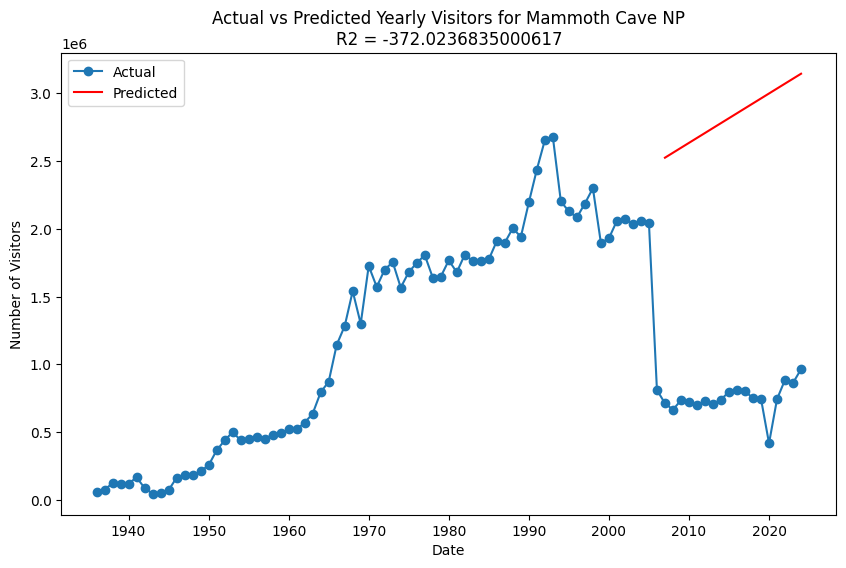

showing


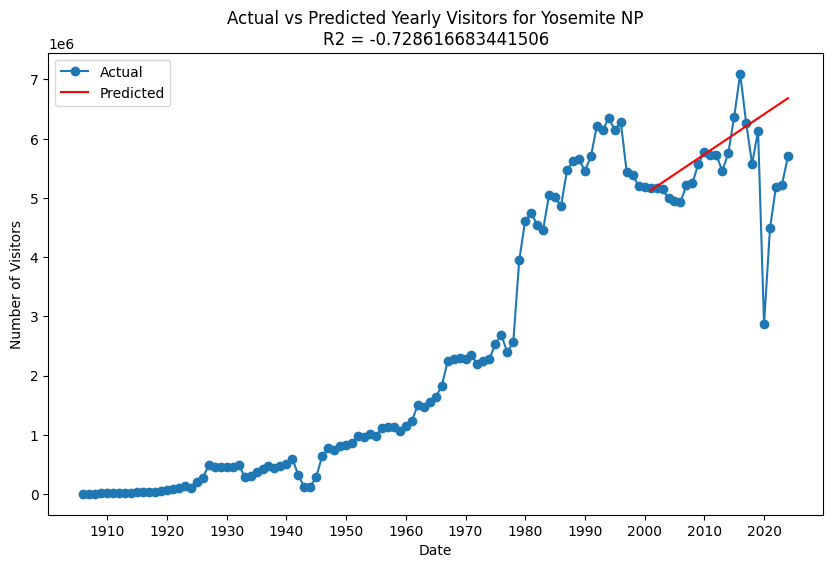

In [5]:
df = pd.read_csv('Datasets/historic_park_data.csv', thousands=',')
df.fillna(0, inplace=True)
df["Date"] = pd.to_datetime(df["Year"].astype(str), format="%Y")

park_list = df['ParkName'].unique()

R2 = {}

for park_name in park_list:
    park = df[df["ParkName"] == park_name].copy()
    park['MonthIndex'] = park['Date'].map(pd.Timestamp.toordinal)

    X = park[['MonthIndex']]
    y = park['Total']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    R2[park_name] = r2_score(y_test, y_pred)

    plt.figure(figsize=(10, 6))
    plt.plot(park.index, park['Total'], label='Actual', marker='o')
    plt.plot(X_test.index, y_pred, label='Predicted', color='red')
    plt.title(f'Actual vs Predicted Yearly Visitors for {park_name}\nR2 = {R2[park_name]}')
    plt.xlabel('Date')
    plt.ylabel('Number of Visitors')
    years = park['Date'].dt.year
    ticks = park.index[years % 10 == 0]
    labels = years[years % 10 == 0]
    plt.xticks(ticks, labels)
    plt.legend()
    # plt.savefig(park_name + '.png')
    if park_name == 'Yosemite NP' or park_name == 'Glacier NP' or park_name == 'Mammoth Cave NP':
        print('showing')
        plt.show()
    plt.close()

### SARIMA Time Series



In [27]:
df = pd.read_csv("Datasets/national_parks_cleaned.csv")

# Separating date column into two columns 'Year' and 'Month'
df['date'] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str)) 

# Running SARIMA for three parks - Glacier, Lake Clark, and Yellowstone
parks = df[df['ParkName'].isin(['Glacier NP', 'Lake Clark NP & PRES', 'Yellowstone NP'])].copy()

# Verifying only three parks are selected
print(parks['ParkName'].unique())
print(parks.head(3))

/var/folders/5n/0jwm44bd7m76wp2nkfsyxtph0000gn/T/ipykernel_29206/61216255.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str))


['Glacier NP' 'Lake Clark NP & PRES' 'Yellowstone NP']
         ParkName UnitCode       ParkType         Region State  Year  \
11647  Glacier NP     GLAC  National Park  Intermountain    MT  1979   
11648  Glacier NP     GLAC  National Park  Intermountain    MT  1979   
11649  Glacier NP     GLAC  National Park  Intermountain    MT  1979   

          Month  RecreationVisits  NonRecreationVisits  RecreationHours  \
11647   January            6357.0                 10.0          25428.0   
11648  February            3480.0                 11.0          13920.0   
11649     March           11790.0                  4.0          47160.0   

       NonRecreationHours  ConcessionerLodging  ConcessionerCamping  \
11647                10.0                  NaN                  NaN   
11648                11.0                  NaN                  NaN   
11649                 4.0                  NaN                  NaN   

       TentCampers  RVCampers  Backcountry  NonRecreationOvernightStay

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.18293D+01    |proj g|=  7.50563D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      4      6      1     0     0   4.591D-06   1.182D+01
  F =   11.819139207858338     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


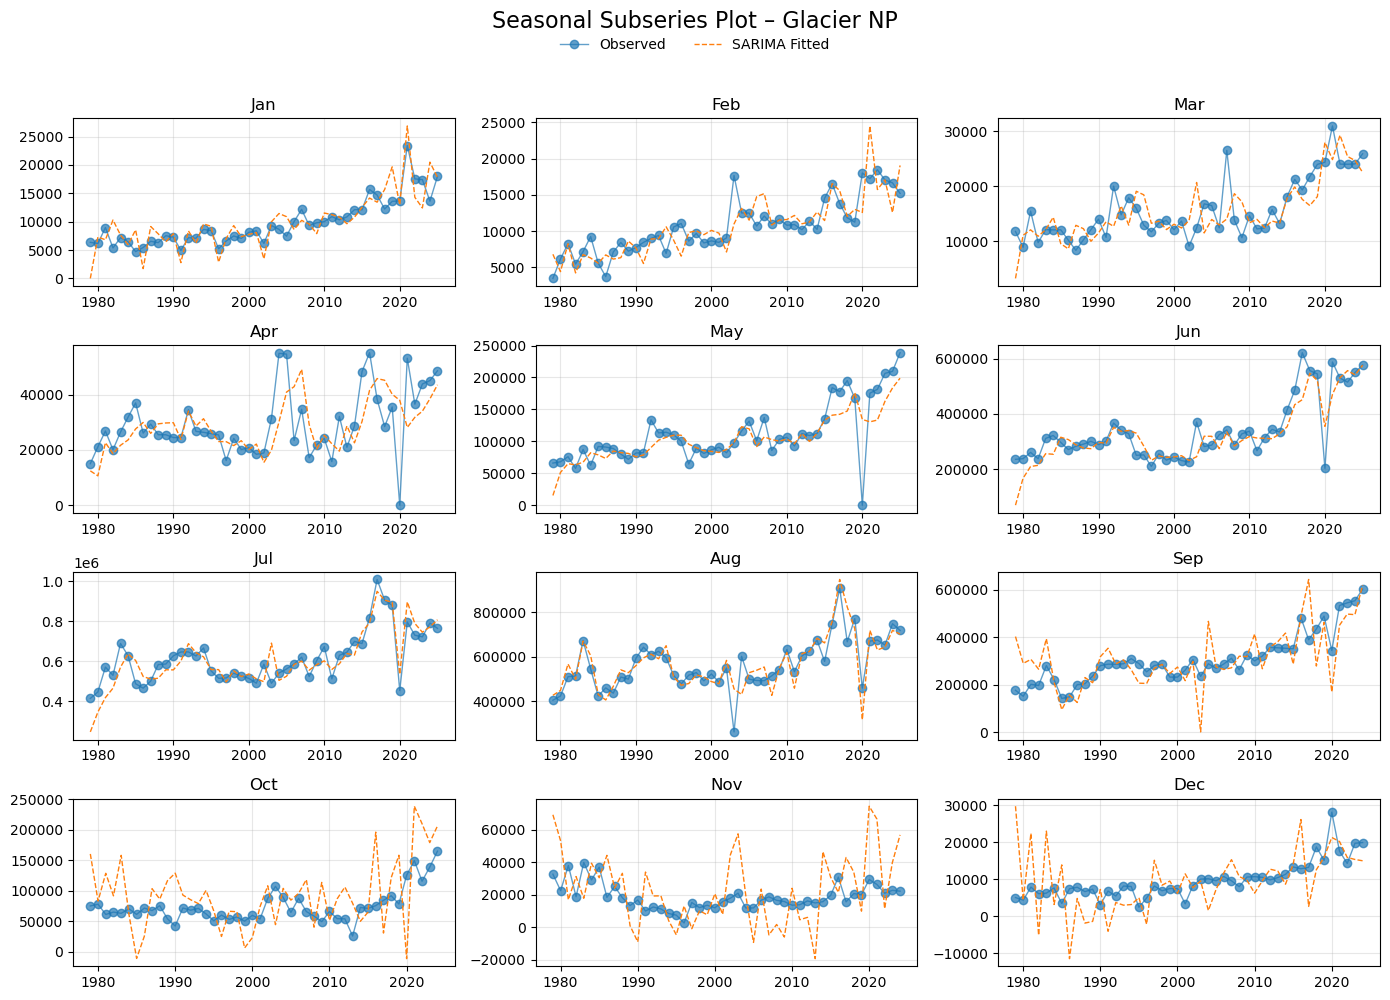

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.47300D+00    |proj g|=  5.13605D-02

At iterate    5    f=  7.46888D+00    |proj g|=  1.73948D-03

At iterate   10    f=  7.46673D+00    |proj g|=  3.83859D-02

At iterate   15    f=  7.45460D+00    |proj g|=  5.06351D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3     17     20      1     0     0   5.301D-06   7.455D+00
  F =   7.4546006690971556     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


 This problem is unconstrained.


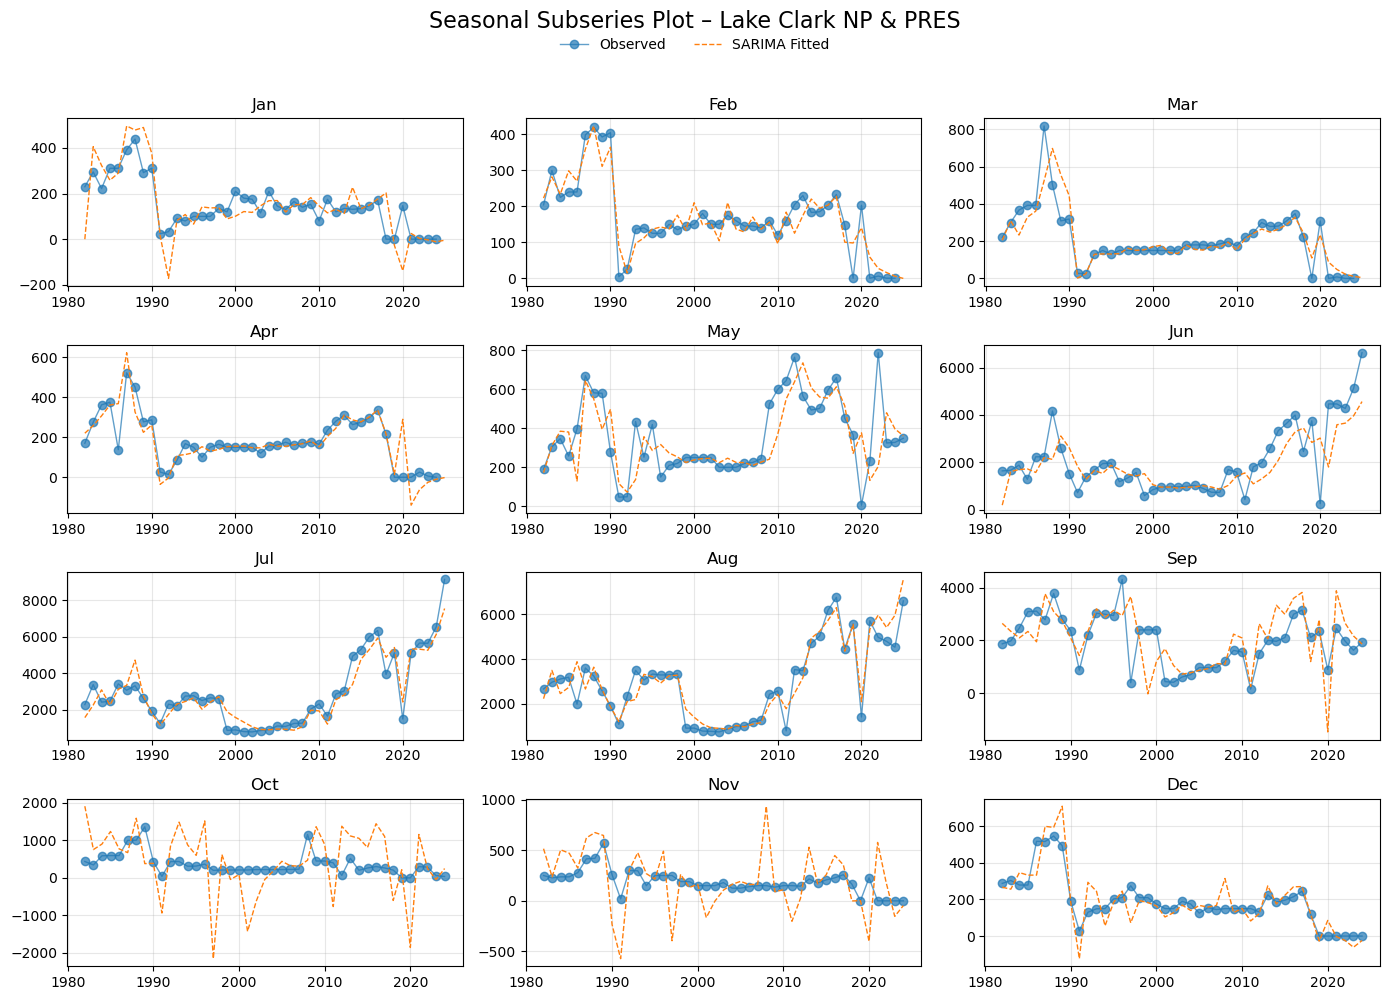

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.19294D+01    |proj g|=  6.40820D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      4      6      1     0     0   5.318D-06   1.192D+01
  F =   11.919973428866538     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


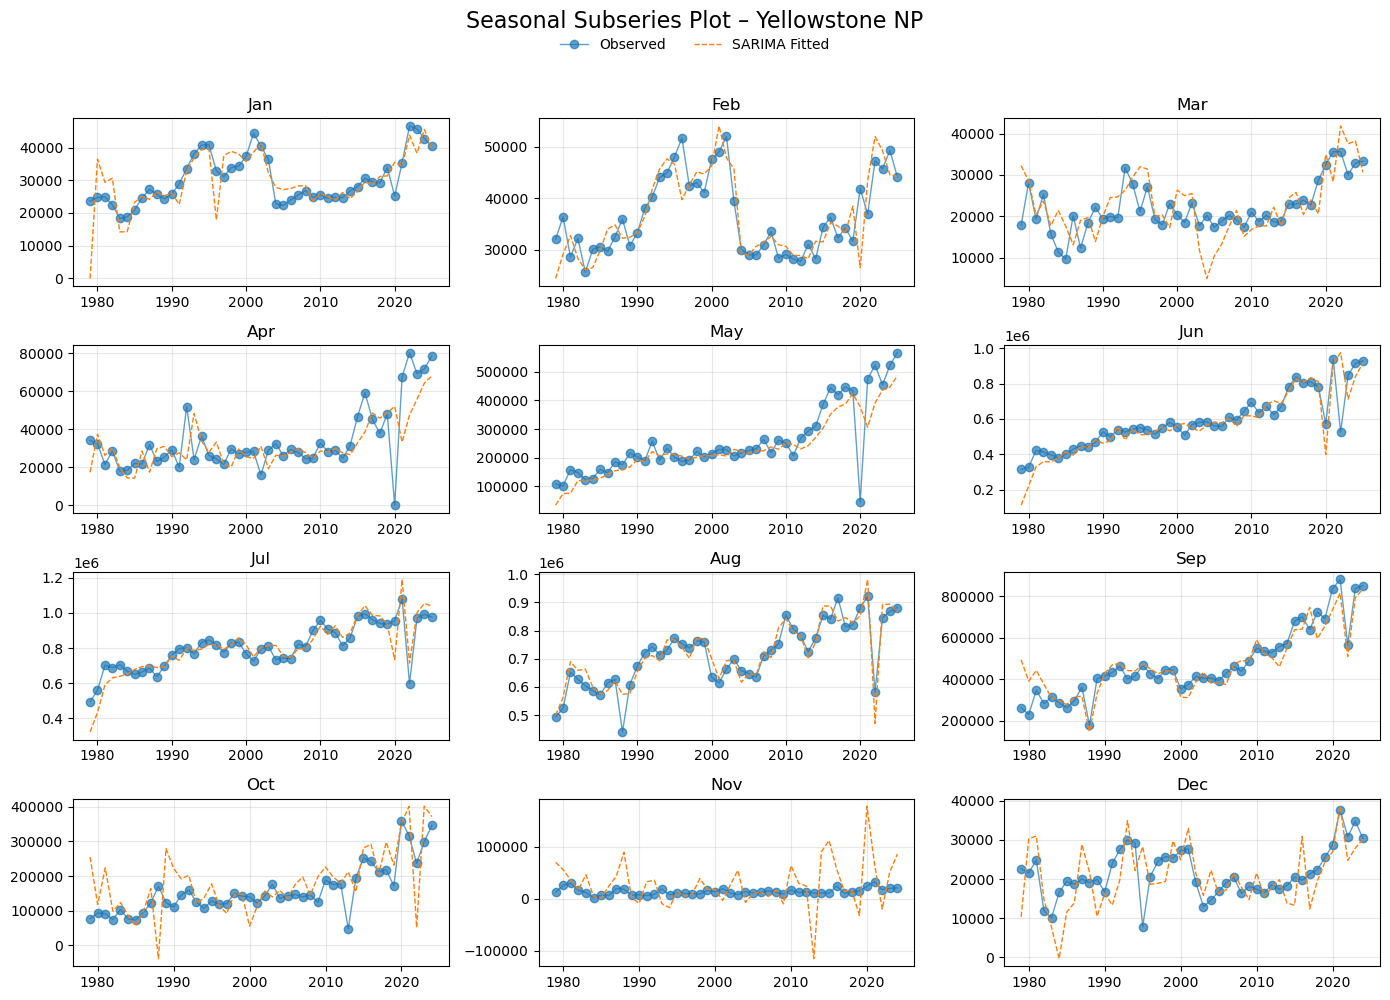

In [ ]:
# Generating visuals (Seasonal Subseries Plot) for each park
for park in parks['ParkName'].unique():
    
    # Filter to park
    park_df = parks[parks['ParkName'] == park].copy()
    park_df = park_df.set_index("date").asfreq("MS")

    # Running SARIMA for each park
    model = SARIMAX(park_df["RecreationVisits"],
                    order=(0,1,1),
                    seasonal_order=(0,1,1,12))
    results = model.fit()

    park_df["Fitted"] = results.fittedvalues
    
    park_df['Year'] = park_df.index.year
    park_df['Month'] = park_df.index.month
    
    fig, axes = plt.subplots(4, 3, figsize=(14, 10))
    axes = axes.flatten()
    
    month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']
    
    for month in range(1, 13):
        ax = axes[month - 1]
        monthly = park_df[park_df['Month'] == month]

        ax.plot(monthly['Year'], monthly['RecreationVisits'], marker='o', linewidth=1, alpha=0.7, label='Observed')
        
        # SARIMA overlay
        ax.plot(monthly['Year'], monthly['Fitted'], linestyle='--', linewidth=1, label='SARIMA Fitted')
        
        ax.set_title(month_names[month - 1])
        ax.grid(alpha=0.3)
    
    # Add legend to the figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), 
               ncol=2, frameon=False)
    
    plt.suptitle(f"Seasonal Subseries Plot – {park}", fontsize=16, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    plt.show()
    plt.close()

### Majority Voting

To combine the anomaly data for each individual park into a list of anomaly years that are consistent across a large number of parks, we used majority voting. If the year was marked as an anomaly for more than a third of the parks where data was available, it was counted in our final list of anomaly years. For some of the earlier years there were not a lot of parks with data collected so we standardized the majority threshold by using the percentage of parks with data available for that year.

In [6]:
def majority_vote_anomalies(folder_path):
    availability_counts = {}

    anomaly_counts = {}

    # Process each CSV file
    for filename in os.listdir(folder_path):
        if filename.endswith(".csv"):
            file_path = os.path.join(folder_path, filename)
            df = pd.read_csv(file_path)

            # Skip if required columns missing
            if "Date" not in df.columns or "Is_Anomaly" not in df.columns:
                print(f"Skipping {filename}: missing required columns.")
                continue

            # Count which dates appear in this park
            for _, row in df.iterrows():
                date = row["Date"]

                # Increase availability count
                availability_counts[date] = availability_counts.get(date, 0) + 1

                # Increase anomaly count only if True
                if bool(row["Is_Anomaly"]):
                    anomaly_counts[date] = anomaly_counts.get(date, 0) + 1

    dates = []

    for date, avail_count in availability_counts.items():
        anomaly_count = anomaly_counts.get(date, 0)

        dates.append((date, anomaly_count/avail_count, anomaly_count, avail_count))

    dates.sort(key=lambda x: x[1])

    dates.reverse()

    dates = pd.DataFrame(dates)

    dates.columns = ['Date','Percentage','Number_Anomalies','Parks_with_Data']

    return dates

folder = "knn_anomalies/results/combined"
anomalies = majority_vote_anomalies(folder)

anomalies.head(15)

,Date,Percentage,Number_Anomalies,Parks_with_Data
0,1946-01-01,0.780488,32,41
1,2021-01-01,0.682540,43,63
2,2022-01-01,0.650794,41,63
3,2020-01-01,0.587302,37,63
4,1945-01-01,0.439024,18,41
5,2023-01-01,0.380952,24,63
6,1909-01-01,0.375000,3,8
7,1943-01-01,0.375000,15,40
8,1915-01-01,0.363636,4,11
9,2024-01-01,0.349206,22,63


### Average Year-over-Year Change

In [36]:
# Configuration

TIME_PERIODS = [
    {'start': 1904, 'end': 1930, 'name': 'Early Era'},
    {'start': 1931, 'end': 1980, 'name': 'Mid-Century Era'},
    {'start': 1981, 'end': 2024, 'name': 'Modern Era'}
]
YEARS_TO_EXCLUDE = [2020, 2021]
MIN_PARKS_REQUIRED = 1

# Asymmetric Z-score thresholds for outlier detection
POSITIVE_Z_THRESHOLD = 1.5
NEGATIVE_Z_THRESHOLD = 1.0 

print(f"{'='*80}")
print(f"MULTI-PERIOD PARK VISITATION ANALYSIS")
for period in TIME_PERIODS:
    print(f"  - {period['name']}: {period['start']}-{period['end']}")
print(f"Outlier Thresholds: +{POSITIVE_Z_THRESHOLD} SD (increases), -{NEGATIVE_Z_THRESHOLD} SD (decreases)")
print(f"{'='*80}")

MULTI-PERIOD PARK VISITATION ANALYSIS
  - Early Era: 1904-1930
  - Mid-Century Era: 1931-1980
  - Modern Era: 1981-2024
Outlier Thresholds: +1.5 SD (increases), -1.0 SD (decreases)


In [34]:
# Load data

df_raw = pd.read_csv('Datasets/historic_park_data.csv')
df_raw['Total'] = (
    df_raw['Total']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# print("Raw data shape:", df_raw.shape)

# Aggregate to annual totals
df_annual = df_raw.groupby(['ParkName', 'Year'])['Total'].sum().reset_index()

# Pivot to parks × years
df_pivot = df_annual.pivot(index='ParkName', columns='Year', values='Total')
df_all = df_pivot.sort_index(axis=1)


ANALYZING: Early Era (1904-1930) — COVID INCLUDE
Years in period: 27
Year range: 1904 to 1930
Parks with data (first year): 0
Parks with data (last year): 24

Period Statistics:
  Mean change: 5,263
  Std dev:   5,704

Outlier Years in Early Era (include): [1906, 1910, 1914, 1918, 1919, 1925]


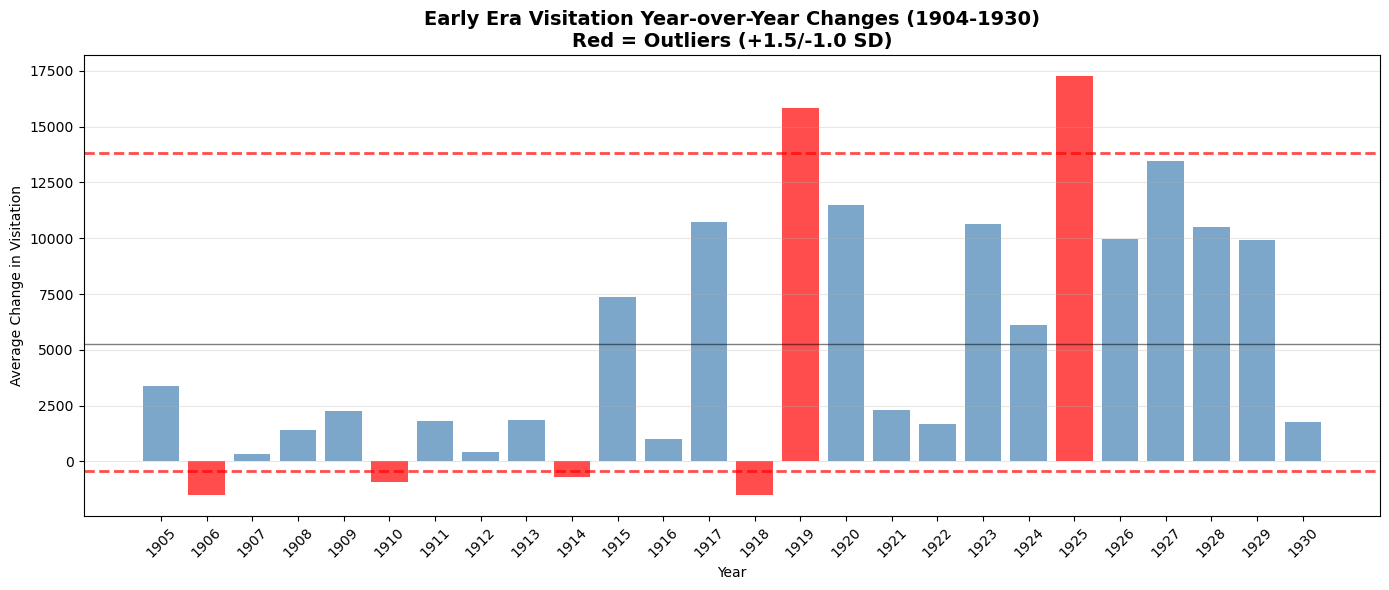


--- Early Era (include) Summary ---
Years analyzed: 26
Outlier years: 6

ANALYZING: Mid-Century Era (1931-1980) — COVID INCLUDE
Years in period: 50
Year range: 1931 to 1980
Parks with data (first year): 0
Parks with data (last year): 55

Period Statistics:
  Mean change: 31,873
  Std dev:   59,646

Outlier Years in Mid-Century Era (include): [1942, 1943, 1971, 1974, 1979]


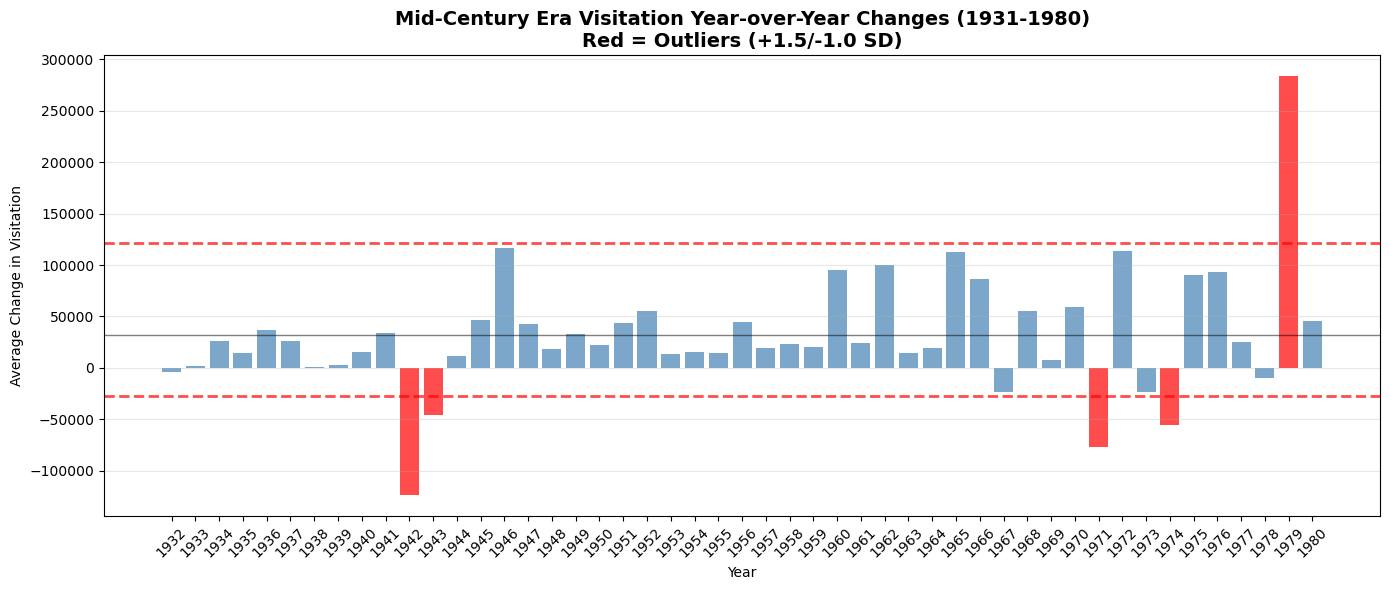


--- Mid-Century Era (include) Summary ---
Years analyzed: 49
Outlier years: 5

ANALYZING: Modern Era (1981-2024) — COVID INCLUDE
Years in period: 44
Year range: 1981 to 2024
Parks with data (first year): 0
Parks with data (last year): 63

Period Statistics:
  Mean change: 17,409
  Std dev:   113,713

Outlier Years in Modern Era (include): [2020, 2021]


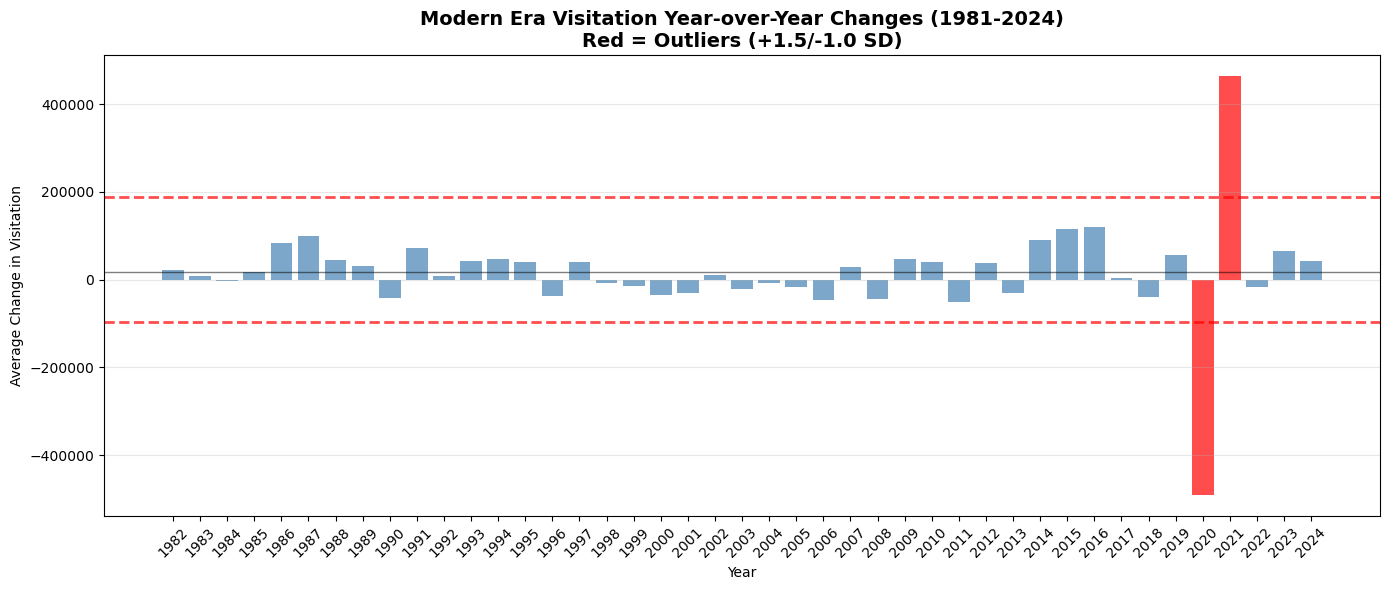


--- Modern Era (include) Summary ---
Years analyzed: 43
Outlier years: 2

ANALYZING: Modern Era (1981-2024) — COVID EXCLUDE
Years in period: 42
Year range: 1981 to 2024
Parks with data (first year): 0
Parks with data (last year): 63

Period Statistics:
  Mean change: 18,258
  Std dev:   47,111

Outlier Years in Modern Era (exclude): [1987, 1990, 1996, 2000, 2001, 2006, 2008, 2011, 2013, 2014, 2015, 2016, 2018, 2022]


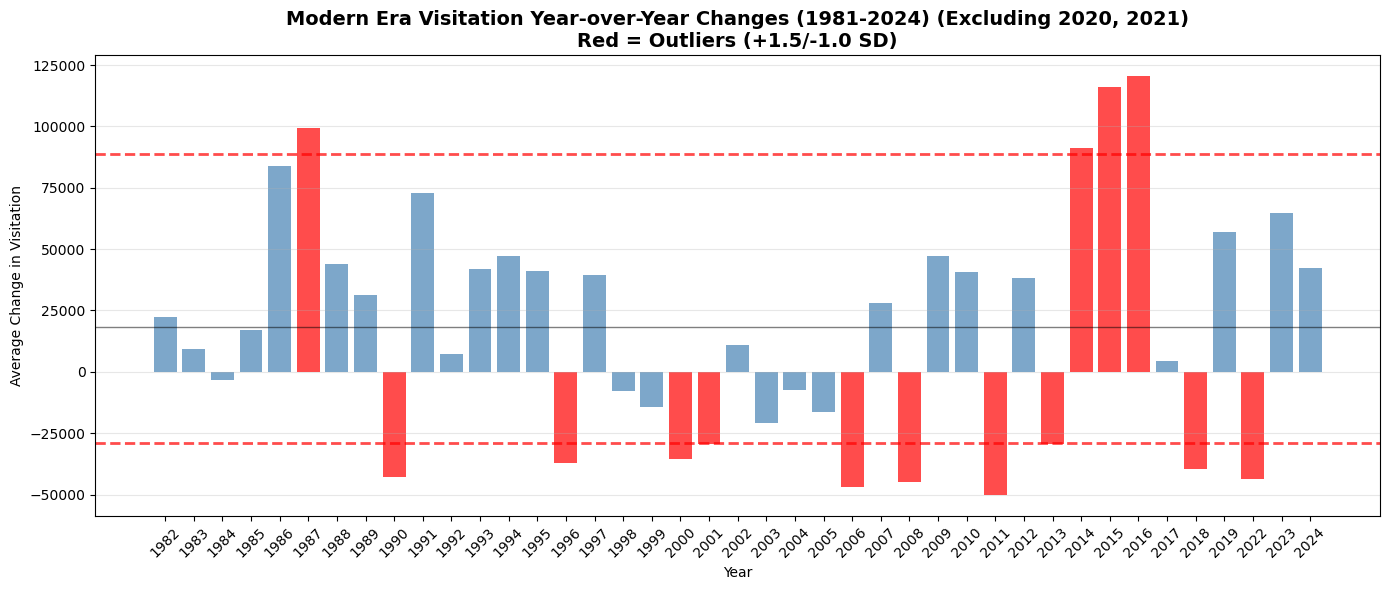


--- Modern Era (exclude) Summary ---
Years analyzed: 41
Outlier years: 14


In [47]:
# Process Each Time Period

all_results = []

for period in TIME_PERIODS:
    START_YEAR = period['start']
    END_YEAR = period['end']
    PERIOD_NAME = period['name']

    # Determine if this is the last time period
    is_last_period = (period == TIME_PERIODS[-1])

    # Modes to plot last period with and without COVID years
    covid_modes = ["include", "exclude"] if is_last_period else ["include"]

    for covid_mode in covid_modes:

        EXCLUDE_COVID = (covid_mode == "exclude")

        print("\n" + "="*80)
        print(f"ANALYZING: {PERIOD_NAME} ({START_YEAR}-{END_YEAR}) — COVID {covid_mode.upper()}")
        print("="*80)

        # Filter to this period's years
        period_years = [y for y in df_all.columns if START_YEAR <= y <= END_YEAR]

        # Only exclude COVID in last period
        if EXCLUDE_COVID:
            period_years = [y for y in period_years if y not in YEARS_TO_EXCLUDE]

        df = df_all[period_years]

        print(f"Years in period: {len(df.columns)}")
        print(f"Year range: {df.columns.min()} to {df.columns.max()}")

        # Calculate YoY changes
        yoy_changes = df.diff(axis=1)
        valid_parks_per_year = yoy_changes.notna().sum(axis=0)

        print(f"Parks with data (first year): {valid_parks_per_year.iloc[0] if len(valid_parks_per_year) > 0 else 0}")
        print(f"Parks with data (last year): {valid_parks_per_year.iloc[-1] if len(valid_parks_per_year) > 0 else 0}")

        # Z-scores per park
        z_scores = pd.DataFrame(index=yoy_changes.index, columns=yoy_changes.columns)
        for park in yoy_changes.index:
            park_changes = yoy_changes.loc[park].dropna()
            if len(park_changes) > 0:
                mc = park_changes.mean()
                sc = park_changes.std()
                if sc > 0:
                    z_scores.loc[park] = (yoy_changes.loc[park] - mc) / sc

        # Park-level outliers
        park_threshold = min(POSITIVE_Z_THRESHOLD, NEGATIVE_Z_THRESHOLD)
        outliers_z = z_scores.abs() > park_threshold

        # Aggregate analysis
        aggregate_changes = yoy_changes.mean(axis=0, skipna=True)
        enough_data = valid_parks_per_year >= MIN_PARKS_REQUIRED
        agg_filtered = aggregate_changes[enough_data]

        if len(agg_filtered) < 3:
            print(f"Insufficient data for period {PERIOD_NAME} - skipping")
            continue

        agg_mean = agg_filtered.mean()
        agg_std = agg_filtered.std()

        print(f"\nPeriod Statistics:")
        print(f"  Mean change: {agg_mean:,.0f}")
        print(f"  Std dev:   {agg_std:,.0f}")

        if agg_std == 0 or pd.isna(agg_std):
            print("No variation — skipping")
            continue

        aggregate_z = (agg_filtered - agg_mean) / agg_std

        outlier_years = aggregate_z[
            (aggregate_z > POSITIVE_Z_THRESHOLD) |
            (aggregate_z < -NEGATIVE_Z_THRESHOLD)
        ]

        print(f"\nOutlier Years in {PERIOD_NAME} ({covid_mode}): {list(outlier_years.index)}")

        # =====================================================================
        # Visualization
        # =====================================================================
        plt.figure(figsize=(14, 6))

        colors = [
            'red' if (z > POSITIVE_Z_THRESHOLD or z < -NEGATIVE_Z_THRESHOLD)
            else 'steelblue'
            for z in aggregate_z
        ]

        plt.bar(
            agg_filtered.index.astype(str),
            agg_filtered.values,
            color=colors,
            alpha=0.7
        )

        # Threshold lines
        plt.axhline(agg_mean + POSITIVE_Z_THRESHOLD * agg_std,
                    color='red', linestyle='--', linewidth=2, alpha=0.7)
        plt.axhline(agg_mean - NEGATIVE_Z_THRESHOLD * agg_std,
                    color='red', linestyle='--', linewidth=2, alpha=0.7)
        plt.axhline(agg_mean, color='black', linestyle='-', linewidth=1, alpha=0.5)

        # Title
        if EXCLUDE_COVID:
            plt.title(
                f"{PERIOD_NAME} Visitation Year-over-Year Changes ({START_YEAR}-{END_YEAR}) (Excluding 2020, 2021)\n"
                f"Red = Outliers (+{POSITIVE_Z_THRESHOLD}/-{NEGATIVE_Z_THRESHOLD} SD)",
                fontsize=14, fontweight='bold'
            )
        else:
           plt.title(
                f"{PERIOD_NAME} Visitation Year-over-Year Changes ({START_YEAR}-{END_YEAR})\n"
                f"Red = Outliers (+{POSITIVE_Z_THRESHOLD}/-{NEGATIVE_Z_THRESHOLD} SD)",
                fontsize=14, fontweight='bold'
            ) 

        plt.xlabel("Year")
        plt.ylabel("Average Change in Visitation")
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()

        plt.show()
        plt.close()

        # =====================================================================
        # Store results
        # =====================================================================
        is_outlier = (aggregate_z > POSITIVE_Z_THRESHOLD) | (aggregate_z < -NEGATIVE_Z_THRESHOLD)

        results_df = pd.DataFrame({
            "Period": PERIOD_NAME,
            "Year": agg_filtered.index,
            "Average_Change": agg_filtered.values,
            "Z_Score": aggregate_z.values,
            "Is_Outlier": is_outlier.values,
            "Outlier_Type": [
                ("Positive" if z > 0 else "Negative") if abs(z) > park_threshold else "None"
                for z in aggregate_z
            ],
            "Parks_With_Data": valid_parks_per_year[enough_data].values,
            "Period_Mean": agg_mean,
            "Period_StdDev": agg_std,
            "COVID_Mode": covid_mode
        })

        all_results.append(results_df)

        # Summary
        print(f"\n--- {PERIOD_NAME} ({covid_mode}) Summary ---")
        print(f"Years analyzed: {len(agg_filtered)}")
        print(f"Outlier years: {len(outlier_years)}")


# Summary


# Gen AI Statement
